# 1팀 프로젝트

- ObjectDetection
- 프로젝트 개요
  - 지금까지 학습하신 커리큘럼 초반부의 내용들을 토대로, **이미지 인식 기술을 헬스케어 분야에 접목해보는** 프로젝트를 진행해봅시다.
  - 여러분들을 헬스케어 스타트업 : 헬스잇(Health Eat) 의 AI 엔지니어링 팀이라고 가정해 볼게요.
      - 헬스잇의 AI 엔지니어링 팀은 유저가 본인의 모바일 애플리케이션으로 자신이 복용중인 약 사진을 찍었을 때, 이미지 인식을 통해 해당 약에 대한 정보를 확인할 수 있는 모델을 만들어야하는 미션을 부여받았습니다.
      - 기업에서는 이를 통해 유저의 건강 상태 및 함께 복용하면 안되는 약 등 헬스케어 정보를 유저들에게 제공함으로써 비즈니스적인 가치를 만들어낼 수 있겠죠.
  - 사진 속에 있는 최대 4개의 알약의 이름(클래스)과 위치(바운딩 박스)를 검출하는 모델을 구현하고, 성능을 지속적으로 개선해나가는 것이 프로젝트의 목표입니다.


In [ ]:

# 1. 기본 Python 라이브러리 (운영체제, 파일, 연산 등)
import os
import json
import gc
import copy
import random
import logging
import subprocess
import unicodedata
from collections import Counter, defaultdict
from typing import Dict, List, Tuple

# 2. 데이터 분석 및 이미지 처리
import pandas as pd
import numpy as np
from PIL import Image

# 3. 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import seaborn as sns

# 4. PyTorch (딥러닝 코어)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# 5. Torchvision (컴퓨터 비전 모델 및 데이터 증강)
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms.v2 as v2
from torchvision import tv_tensors

# 6. 유틸리티 및 진행률 표시
from tqdm.auto import tqdm

# 7. 구글 코랩 전용 설정
from google.colab import drive, files

# =====================================================================
# 로깅 및 디바이스(GPU) 설정
# =====================================================================
# 로깅 설정 (INFO 레벨 출력)
logging.basicConfig(level=logging.INFO, format='%(asctime)s - [%(levelname)s] - %(message)s')
logger = logging.getLogger(__name__)

# 구글 드라이브 마운트
drive.mount('/content/drive')

# 디바이스 설정 (GPU 활성화)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"현재 할당된 연산 디바이스: {DEVICE}")

# 한글 폰트 설정 (Colab 전용)
logger.info("한글 폰트(NanumGothic) 설정을 시작합니다...")
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
subprocess.run(['fc-cache', '-fv'], capture_output=True)
try:
    mpl.font_manager.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    mpl.rc('font', family='NanumGothic')
    plt.rcParams['axes.unicode_minus'] = False
    logger.info("✅ 한글 폰트 설정 완료.")
except Exception as e:
    logger.warning(f"폰트 설정 실패 (기본 폰트 사용): {e}")

## EDA(탐색적 데이터 분석)

 - 설정의 중앙 집중화 : 흩어져 있는 경로와 환경의 변수를 하나의 클래스로 묶어 추후에 유지보수와 실험 관리를 편하게 만듬
 - 데이터 시각화 검증 : 실제 바운딩 박스가 어떻게 그려지는지 눈으로 확인 할수 있도록 함

Mounted at /content/drive


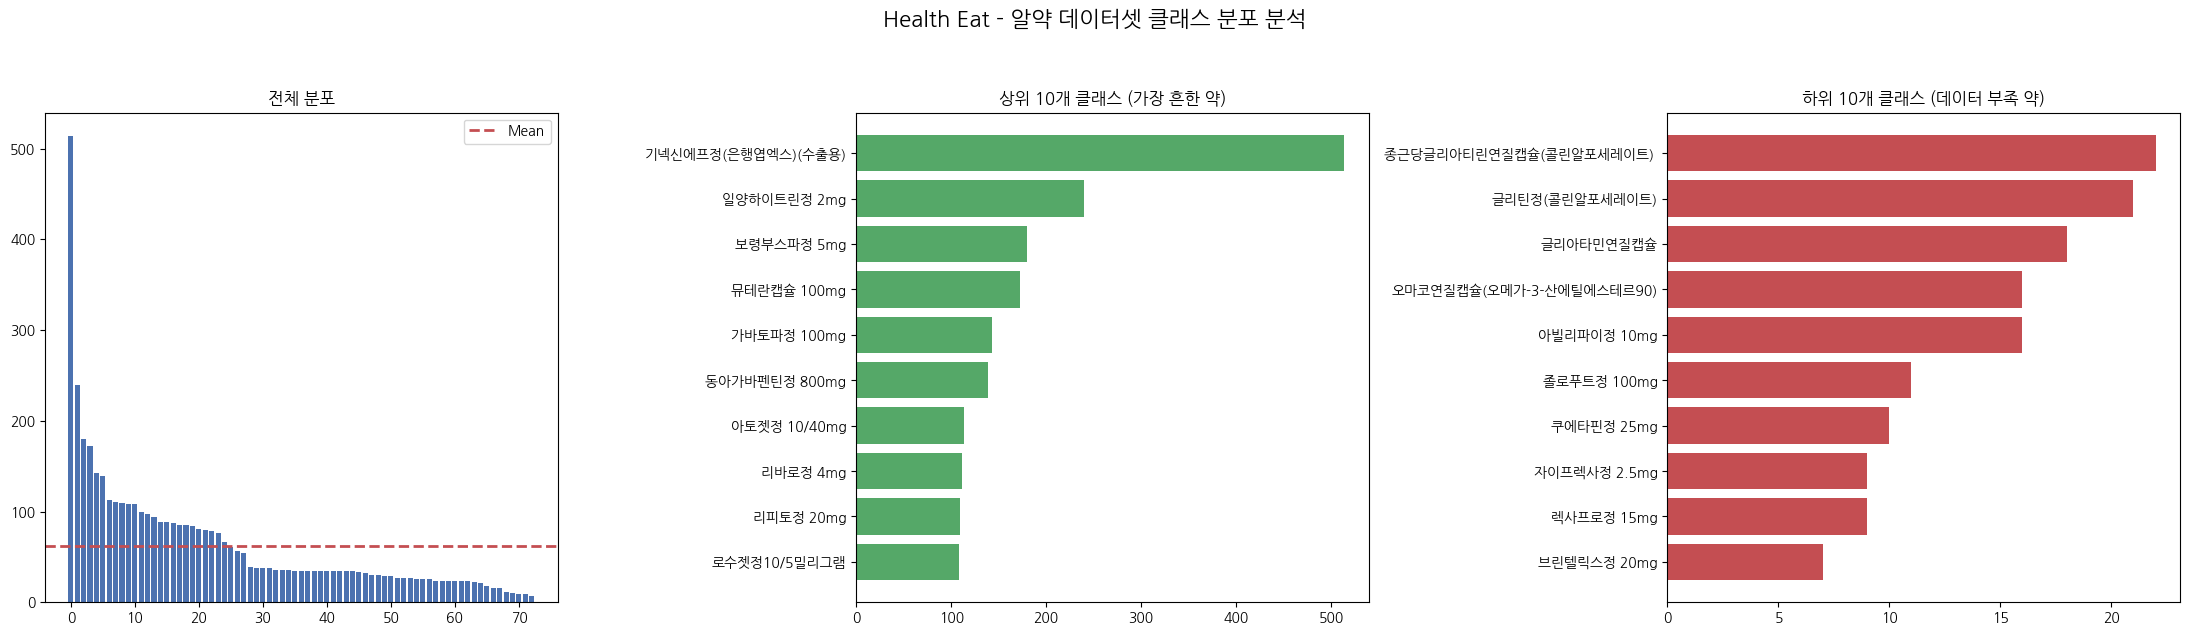

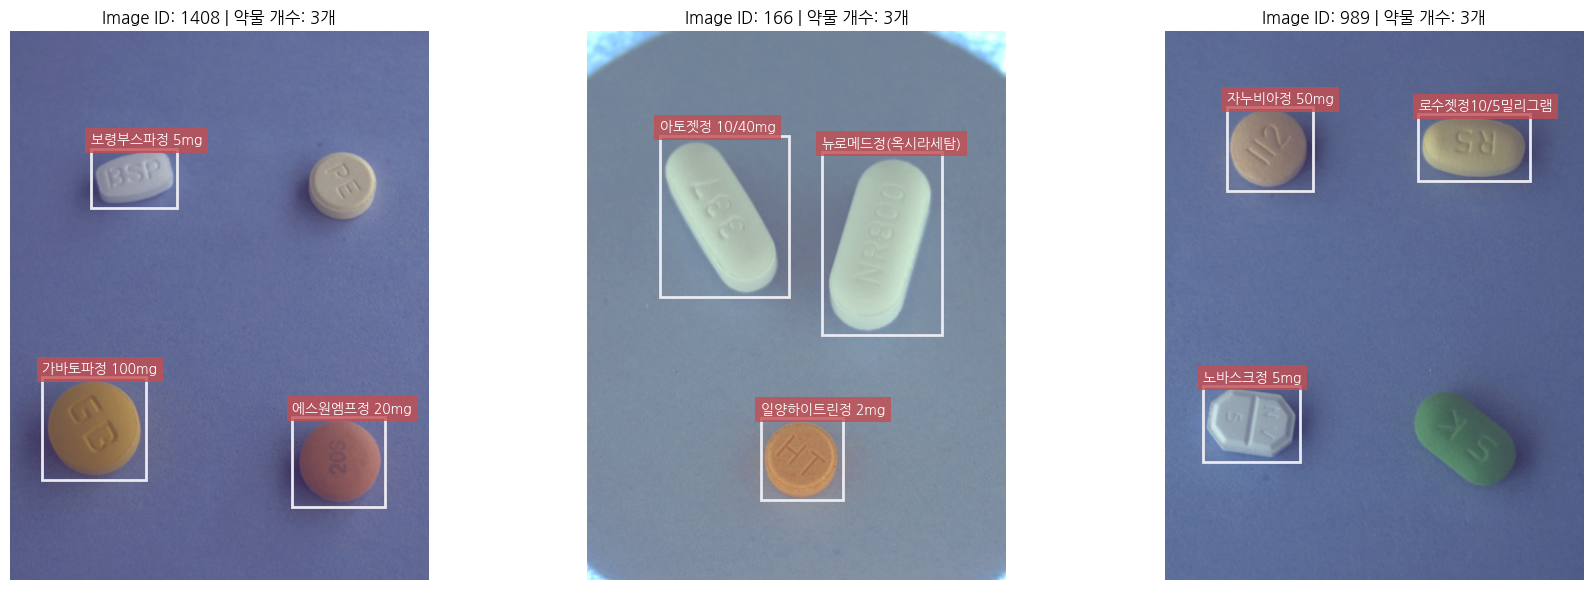

In [ ]:
# =====================================================================
# [2단계] 프로젝트 통합 설정 (Configuration)
# =====================================================================
class Config:
    def __init__(self):
        # 경로 정규화 함수
        def normalize_path(path):
            return unicodedata.normalize('NFC', path).strip()

        # 기본 경로 설정
        self.BASE_DIR = normalize_path("/content/drive/MyDrive/data/초급_프로젝트/dataset/")

        self.TRAIN_JSON = os.path.join(self.BASE_DIR, "merged_annotations_train_final.json")
        self.TEST_JSON = os.path.join(self.BASE_DIR, "merged_annotations_test_final.json")
        self.TRAIN_IMG_DIR = os.path.join(self.BASE_DIR, "train_images")
        self.TEST_IMG_DIR = os.path.join(self.BASE_DIR, "test_images")

CFG = Config()

# =====================================================================
# [4단계] 데이터 무결성 검증 및 EDA (탐색적 데이터 분석)
# =====================================================================
logger.info("데이터 경로 및 무결성을 검증합니다.")
paths = [CFG.TRAIN_JSON, CFG.TEST_JSON, CFG.TRAIN_IMG_DIR, CFG.TEST_IMG_DIR]
for path in paths:
    if not os.path.exists(path):
        logger.error(f"경로 누락: {path}")
        raise FileNotFoundError(f"필수 경로를 찾을 수 없습니다: {path}")

# JSON 로드
with open(CFG.TRAIN_JSON, 'r', encoding='utf-8') as f:
    train_data = json.load(f)

id2name = {cat['id']: cat['name'] for cat in train_data['categories']}
logger.info(f"학습 이미지: {len(train_data['images']):,}장 | 어노테이션: {len(train_data['annotations']):,}개 | 클래스: {len(id2name)}개")

# 클래스 분포 분석
cat_counter = Counter(ann['category_id'] for ann in train_data['annotations'])
df_class = pd.DataFrame([
    {'category_id': cid, 'name': id2name.get(cid, 'Unknown'), 'count': cnt}
    for cid, cnt in cat_counter.most_common()
])

# 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Health Eat - 알약 데이터셋 클래스 분포 분석', fontsize=16, fontweight='bold', y=1.05)

# 전체 분포
axes[0].bar(range(len(df_class)), df_class['count'], color='#4C72B0')
axes[0].axhline(df_class['count'].mean(), color='#C44E52', linestyle='--', linewidth=2, label='Mean')
axes[0].set_title('전체 분포', fontsize=12)
axes[0].legend()

# 상위 10개
top10 = df_class.head(10).reset_index(drop=True)
axes[1].barh(range(10), top10['count'], color='#55A868')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(top10['name'])
axes[1].invert_yaxis()
axes[1].set_title('상위 10개 클래스 (가장 흔한 약)', fontsize=12)

# 하위 10개
bot10 = df_class.tail(10).reset_index(drop=True)
axes[2].barh(range(10), bot10['count'], color='#C44E52')
axes[2].set_yticks(range(10))
axes[2].set_yticklabels(bot10['name'])
axes[2].invert_yaxis()
axes[2].set_title('하위 10개 클래스 (데이터 부족 약)', fontsize=12)

plt.tight_layout()
plt.show()

# =====================================================================
# [5단계] 실측 데이터(Ground Truth) 바운딩 박스 시각화 검증
# =====================================================================
def visualize_ground_truth(json_data, img_dir, num_samples=3):
    """실제 이미지 위에 JSON에 기록된 정답 바운딩 박스를 그려서 올바르게 라벨링되었는지 검증합니다."""
    logger.info("실제 이미지 샘플과 정답 바운딩 박스를 시각화합니다.")

    # 랜덤으로 이미지 선택
    sample_images = random.sample(json_data['images'], num_samples)

    # 이미지 ID별 어노테이션 맵핑
    ann_map = {}
    for ann in json_data['annotations']:
        ann_map.setdefault(ann['image_id'], []).append(ann)

    fig, axes = plt.subplots(1, num_samples, figsize=(6 * num_samples, 6))
    if num_samples == 1: axes = [axes]

    for ax, img_info in zip(axes, sample_images):
        img_path = os.path.join(img_dir, img_info['file_name'])
        image = Image.open(img_path).convert("RGB")
        ax.imshow(image)

        # 바운딩 박스 그리기
        anns = ann_map.get(img_info['id'], [])
        for ann in anns:
            x, y, w, h = ann['bbox']
            cat_name = id2name.get(ann['category_id'], 'Unknown')

            # 사각형 그리기
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='#EAEAF2', facecolor='none')
            ax.add_patch(rect)
            # 텍스트 라벨 (가독성을 위해 배경색 추가)
            ax.text(x, y - 10, cat_name, color='white', fontsize=10, fontweight='bold',
                    bbox=dict(facecolor='#C44E52', edgecolor='none', alpha=0.8))

        ax.set_title(f"Image ID: {img_info['id']} | 약물 개수: {len(anns)}개")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# 샘플 3장 시각화 실행
visualize_ground_truth(train_data, CFG.TRAIN_IMG_DIR, num_samples=3)

## Dataset & DataLoader

 - `transforms.v2`와 `tv_tensors`를 사용하여, **이미지를 증강할 때 해당 이미지 안의 바운딩 박스 좌표도 자동으로 완벽하게 동기화되어 변환**되도록 파이프라인을 구축



In [ ]:
# =====================================================================
# [1단계] 최적화된 Dataset 클래스 정의
# =====================================================================

class HealthEatDataset(Dataset):
    def __init__(self, json_path: str, img_dir: str, transforms=None):
        super().__init__()
        self.img_dir = img_dir
        self.transforms = transforms

        # 1. JSON 데이터 로드
        logger.info(f"데이터셋 로딩 중: {json_path}")
        with open(json_path, 'r', encoding='utf-8') as f:
            self.data = json.load(f)

        # 2. 이미지 정보 매핑 (id -> image info)
        self.images = {img['id']: img for img in self.data['images']}
        self.image_ids = list(self.images.keys())

        # 3. 클래스 라벨 매핑 (Background = 0, 실제 객체는 1부터 시작)
        unique_cats = sorted([cat['id'] for cat in self.data['categories']])
        self.cat2label = {cid: idx + 1 for idx, cid in enumerate(unique_cats)}

        # ★ 4. 병목 현상 제거 (O(1) 캐싱 메커니즘)
        self.annotations = defaultdict(list)
        for ann in self.data['annotations']:
            self.annotations[ann['image_id']].append(ann)

    def __len__(self) -> int:
        return len(self.image_ids)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        img_id = self.image_ids[idx]
        img_info = self.images[img_id]

        # 1) 이미지 로드
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        image = Image.open(img_path).convert("RGB")

        # 2) 바운딩 박스 및 라벨 파싱
        boxes, labels = [], []
        for ann in self.annotations.get(img_id, []):
            x, y, w, h = ann['bbox']
            # COCO(x,y,w,h) -> Pascal VOC(x1,y1,x2,y2) 포맷 변환 (Faster R-CNN 표준)
            boxes.append([x, y, x + w, y + h])
            labels.append(self.cat2label[ann['category_id']])

        # 객체가 없는 이미지에 대한 예외 처리 (Robustness)
        if not boxes:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        # ★ v2 API를 위한 tv_tensors 래핑 (이미지-박스 동기화 증강)
        image = tv_tensors.Image(image)
        boxes = tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=image.shape[-2:])

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([img_id])
        }

        # 3) Data Augmentation 적용
        if self.transforms is not None:
            image, target = self.transforms(image, target)

        return image, target


# =====================================================================
# [2단계] Data Augmentation 및 DataLoader 세팅
# =====================================================================
def collate_fn(batch):
    """배치 단위로 데이터를 묶을 때 사용하는 함수 (객체 탐지 필수)"""
    return tuple(zip(*batch))

# Train: 데이터 다양성 확보를 위한 증강 적용
train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.ColorJitter(brightness=0.2, contrast=0.2),
    v2.ToDtype(torch.float32, scale=True) # 기존 ToTensor()를 대체하는 최신 표준
])

# Validation/Test: 증강 없이 텐서 변환만 적용
val_transforms = v2.Compose([
    v2.ToDtype(torch.float32, scale=True)
])

# 인스턴스 생성 (앞서 만든 CFG 객체 재사용)
logger.info("Dataset 및 DataLoader를 초기화합니다...")
train_dataset = HealthEatDataset(CFG.TRAIN_JSON, CFG.TRAIN_IMG_DIR, transforms=train_transforms)
val_dataset = HealthEatDataset(CFG.TEST_JSON, CFG.TEST_IMG_DIR, transforms=val_transforms)

# DataLoader 구축
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2, # 데이터 로딩 병렬화 (Colab 환경 최적화)
    collate_fn=collate_fn,
    pin_memory=True # GPU로 데이터를 더 빠르게 넘기기 위한 설정
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn,
    pin_memory=True
)

logger.info(f"파이프라인 구축 완료! [Train 배치: {len(train_loader)}개 | Val 배치: {len(val_loader)}개]")

## 모델 (Faster R-CNN) 학습 & 루프 구축


 - 객체의 위치(Bounding Box)와 종류(Class)를 동시에 찾아내는 **Faster R-CNN 모델**을 구축하고 학습. **'Data Leakage(데이터 누수 및 오염) 현상'**을 완벽하게 해결하는 데 집중


In [ ]:
# =====================================================================
# [1단계] 학습 준비 (모델, 최적화 도구, 기록장 세팅)
# =====================================================================

logger.info("사전 학습된 Faster R-CNN 모델을 세팅합니다...")
model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
in_features = model.roi_heads.box_predictor.cls_score.in_features
NUM_CLASSES = len(train_dataset.cat2label) + 1
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
model.to(CFG.DEVICE)

optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# =====================================================================
# [2단계] 실무형 학습 루프 (Early Stopping & History Tracking)
# =====================================================================
num_epochs = 15
patience = 4              # 4번 연속으로 최고 기록을 갱신하지 못하면 조기 종료
best_loss = float('inf')
patience_counter = 0
best_model_wts = copy.deepcopy(model.state_dict()) # 최고 성능일 때의 가중치 보관

# 시각화를 위한 기록장 (Phase 5에서 사용됨)
history = {'train_loss': []}

logger.info("본격적인 모델 학습을 시작합니다! (Early Stopping 적용)")

for epoch in range(num_epochs):
    # ---------------------------------------------------------
    # Train Phase
    # ---------------------------------------------------------
    model.train()
    train_loss_sum = 0.0

    train_pbar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Train", leave=False)

    for images, targets in train_pbar:
        images = [img.to(CFG.DEVICE) for img in images]
        targets = [{k: v.to(CFG.DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # 기울기 폭발 방지
        optimizer.step()

        train_loss_sum += losses.item()
        train_pbar.set_postfix({"loss": f"{losses.item():.4f}"})

    avg_train_loss = train_loss_sum / len(train_loader)
    history['train_loss'].append(avg_train_loss) # 기록장에 저장

    scheduler.step()

    # ---------------------------------------------------------
    # Early Stopping & Checkpoint 로직
    # ---------------------------------------------------------
    logger.info(f"Epoch [{epoch+1}/{num_epochs}] 완료 | Train Avg Loss: {avg_train_loss:.4f}")

    # Loss가 기존 최고 기록보다 더 떨어졌다면? (성능 향상)
    if avg_train_loss < best_loss:
        logger.info(f" 최고 기록 갱신! (Loss: {best_loss:.4f} -> {avg_train_loss:.4f})")
        best_loss = avg_train_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0 # 카운터 초기화
    else:
        patience_counter += 1
        logger.info(f"  성능 향상 없음 (Patience: {patience_counter}/{patience})")

        if patience_counter >= patience:
            logger.warning("조기 종료(Early Stopping) 발동! 과적합을 방지하기 위해 학습을 중단합니다.")
            break

# =====================================================================
# [3단계] 최고 성능 모델 저장
# =====================================================================
model.load_state_dict(best_model_wts) # 최고였던 시절의 뇌로 복구
save_path = os.path.join(CFG.BASE_DIR, "healtheat_best_model.pth")
torch.save(model.state_dict(), save_path)
logger.info(f" 학습 완전 종료! 최적의 모델이 저장되었습니다: {save_path}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 225MB/s]


Epoch [1/20] Train:   0%|          | 0/373 [00:00<?, ?it/s]

Epoch [2/20] Train:   0%|          | 0/373 [00:00<?, ?it/s]

Epoch [3/20] Train:   0%|          | 0/373 [00:00<?, ?it/s]

...

Epoch [16/20] Train:   0%|          | 0/373 [00:00<?, ?it/s]

Epoch [17/20] Train:   0%|          | 0/373 [00:00<?, ?it/s]

Epoch [18/20] Train:   0%|          | 0/373 [00:00<?, ?it/s]

Epoch [19/20] Train:   0%|          | 0/373 [00:00<?, ?it/s]

Epoch [20/20] Train:   0%|          | 0/373 [00:00<?, ?it/s]

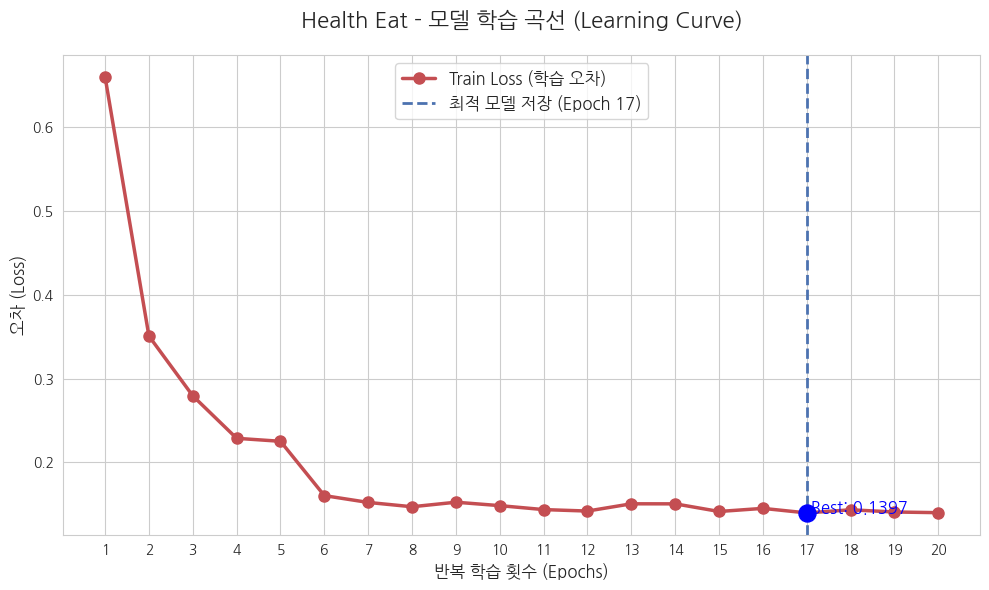

In [ ]:

def plot_learning_curve(history):
    sns.set_style("whitegrid")
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False

    plt.figure(figsize=(10, 6))

    epochs = range(1, len(history['train_loss']) + 1)

    # Train Loss 라인 그리기
    plt.plot(epochs, history['train_loss'], marker='o', linestyle='-', color='#C44E52', linewidth=2.5, markersize=8, label='Train Loss (학습 오차)')

    # 최고 성능 지점 표시
    best_epoch = history['train_loss'].index(min(history['train_loss'])) + 1
    best_loss_val = min(history['train_loss'])

    plt.axvline(x=best_epoch, color='#4C72B0', linestyle='--', linewidth=2, label=f'최적 모델 저장 (Epoch {best_epoch})')
    plt.scatter(best_epoch, best_loss_val, color='blue', s=150, zorder=5)
    plt.text(best_epoch + 0.1, best_loss_val, f"Best: {best_loss_val:.4f}", color='blue', fontweight='bold', fontsize=12)

    plt.title('Health Eat - 모델 학습 곡선 (Learning Curve)', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('반복 학습 횟수 (Epochs)', fontsize=12)
    plt.ylabel('오차 (Loss)', fontsize=12)
    plt.xticks(epochs)
    plt.legend(fontsize=12)

    plt.tight_layout()
    plt.show()

# 위에서 저장한 history 기록장으로 그래프 그리기
plot_learning_curve(history)

## 🎯 [Phase 6] 실전 추론 (Inference) 및 최종 Submission CSV 생성

기나긴 학습이 끝났습니다! 이제 모델이 저장해둔 '가장 똑똑했던 순간(Best Model)'의 뇌 구조를 불러와, 평가용(Test) 이미지에서 알약을 탐지합니다.

### 💡 핵심 추론(Inference) 컨셉
1. **스코어 임계값 (Score Threshold) 필터링:** 모델이 "어... 이건 10% 확률로 타이레놀 같아요"라고 자신 없는 예측을 던진 것은 과감히 버리고, **"최소 45% 이상 확신하는 객체만"** 정답으로 인정하여 정밀도(Precision)를 높입니다.
2. **좌표 및 라벨 원상복구:**
   * 모델이 예측한 `[x1, y1, x2, y2]` 포맷을 다시 평가 양식인 `[x, y, width, height]`로 되돌립니다.
   * 우리가 모델에게 먹이기 편하도록 1번부터 차례대로 매겼던 알약 번호표를, **원래 정답지에 있던 복잡한 고유 번호(category_id)로 다시 매핑**해 줍니다.

In [ ]:
# =====================================================================
# [1단계] 최적 모델 불러오기 및 추론 준비
# =====================================================================

logger.info("최고 성능을 기록했던 Best Model 가중치를 불러옵니다...")
# 아까 Phase 4에서 저장했던 베스트 모델 가중치 로드
save_path = os.path.join(CFG.BASE_DIR, "healtheat_best_model.pth")
model.load_state_dict(torch.load(save_path))
model.eval() # ★ 추론할 때는 반드시 eval() 모드!

# 모델용 라벨(1~73)을 다시 원본 category_id로 돌려놓기 위한 '역방향 사전' 만들기
label2cat = {v: k for k, v in train_dataset.cat2label.items()}

# 테스트 이미지 변환기 (증강 없이 순수하게 텐서 변환만)
test_transforms = v2.Compose([
    v2.ToDtype(torch.float32, scale=True)
])

# =====================================================================
# [2단계] Test 이미지 추론 진행 (Inference Loop)
# =====================================================================
# 테스트 폴더 안의 모든 이미지 파일 목록 가져오기
test_files = [f for f in os.listdir(CFG.TEST_IMG_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
test_files = sorted(test_files) # 정렬해서 순서대로 처리

results = []
annotation_id = 1      # 제출용 파일에 들어갈 순번
SCORE_THRESHOLD = 0.45 # ★ 모델이 45% 이상 확신하는 박스만 남김 (너무 낮으면 쓰레기 박스가 많아짐)

logger.info(f"총 {len(test_files)}장의 테스트 이미지 추론을 시작합니다...")

with torch.no_grad(): # 역전파 안 하니까 메모리/속도 쾌적!
    for filename in tqdm(test_files, desc="추론 진행 중"):
        img_path = os.path.join(CFG.TEST_IMG_DIR, filename)

        # 1) 이미지 열고 텐서로 변환
        image = Image.open(img_path).convert("RGB")
        img_tensor = v2.functional.to_image(image)
        img_tensor, _ = test_transforms(img_tensor, None) # target은 없으므로 None
        img_tensor = img_tensor.to(CFG.DEVICE)

        # 파일명에서 확장자(.jpg 등)를 뺀 순수 이름을 image_id로 사용
        image_id = os.path.splitext(filename)[0]

        # 2) 모델 예측
        outputs = model([img_tensor])[0] # 배치 사이즈 1이라 [0]으로 꺼냄

        # 3) 결과 필터링 및 후처리
        # 설정한 점수(0.45) 이상인 애들만 남깁니다.
        keep = outputs["scores"].cpu() >= SCORE_THRESHOLD
        boxes  = outputs["boxes"].cpu()[keep].numpy()
        labels = outputs["labels"].cpu()[keep].numpy()
        scores = outputs["scores"].cpu()[keep].numpy()

        for box, label, score in zip(boxes, labels, scores):
            x1, y1, x2, y2 = box
            w = x2 - x1
            h = y2 - y1

            # 모델용 라벨 -> 원래 알약 고유 카테고리 ID로 변환
            orig_cat_id = label2cat[label]

            results.append({
                "annotation_id": annotation_id,
                "image_id": image_id,
                "category_id": orig_cat_id,
                "bbox_x": float(x1),
                "bbox_y": float(y1),
                "bbox_w": float(w),
                "bbox_h": float(h),
                "score": float(score),
            })

            annotation_id += 1

# =====================================================================
# [3단계] 최종 Submission CSV 파일 생성
# =====================================================================
df_sub = pd.DataFrame(results)

# (선택) 만약 하나의 사진에 알약이 무조건 4개 이하라는 확실한 룰이 있다면
# 아래 코드의 주석을 풀고 실행하세요. (점수 높은 순으로 최대 4개만 남김)
# df_sub = df_sub.sort_values(by=["image_id", "score"], ascending=[True, False])
# df_sub = df_sub.groupby("image_id").head(4)

# CSV로 저장
output_csv_path = os.path.join(CFG.BASE_DIR, "final_submission.csv")
df_sub.to_csv(output_csv_path, index=False)

logger.info(f" 기나긴 여정이 끝났습니다! 최종 제출 파일이 생성되었습니다: {output_csv_path}")
logger.info(f" 탐지된 총 객체(알약) 수: {len(df_sub)}개")
df_sub.head() # 데이터프레임 앞부분 살짝 구경하기

추론 진행 중:   0%|          | 0/843 [00:00<?, ?it/s]

,annotation_id,image_id,category_id,bbox_x,bbox_y,bbox_w,bbox_h,score
0,1,1,27925,598.901978,669.093323,256.648804,489.217712,0.981422
1,2,1,1899,157.734024,250.561508,203.522934,127.431564,0.977097
2,3,1,16550,553.139587,72.865135,400.659485,402.771912,0.971360
3,4,1,24849,170.076187,740.350464,183.056534,295.705688,0.944175
4,5,10,16547,100.359970,807.651489,242.415756,235.132080,0.981935


## 최종 예측 결과 시각화 (Visualizing Predictions)

 - 모델이 본 적 없는 테스트(Test) 이미지에서 알약을 얼마나 정확하게 찾아냈는지 직접 눈으로 확인합

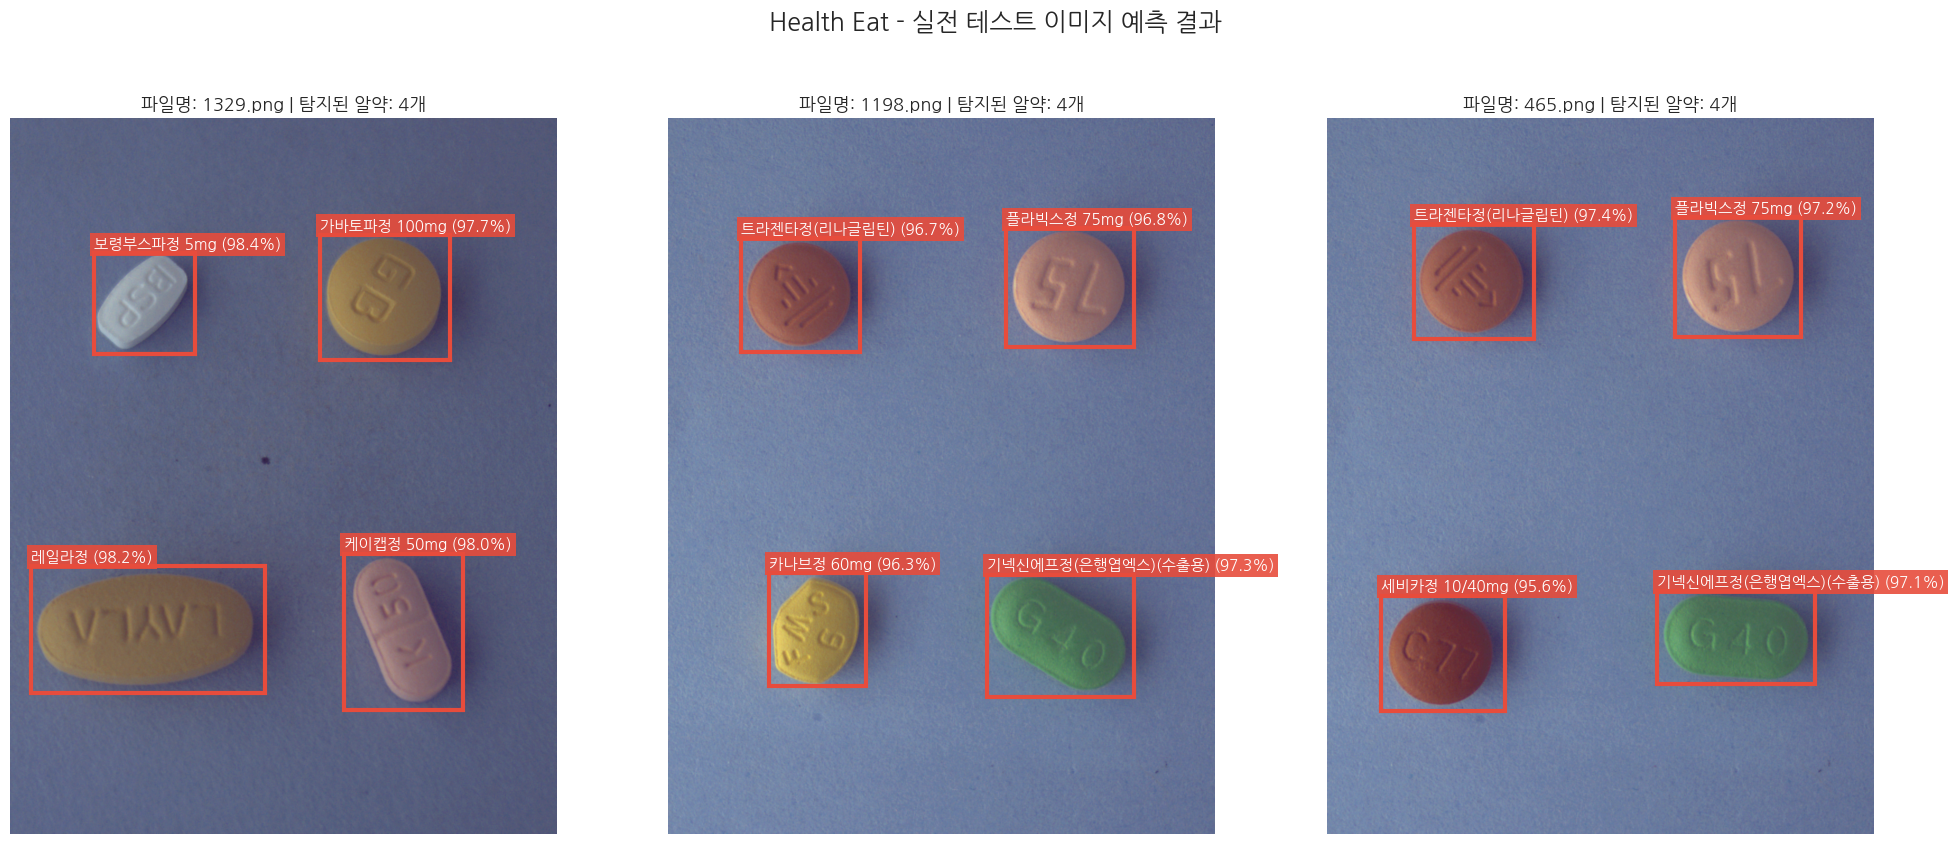

In [ ]:

logger.info("최종 예측 결과를 시각화하여 확인합니다...")

# 1. 방금 예측해서 저장한 CSV 파일 불러오기
submission_path = os.path.join(CFG.BASE_DIR, "final_submission.csv")
df_results = pd.read_csv(submission_path)

# 2. 알약이 탐지된 이미지 중 무작위로 3장 고르기
# (알약이 하나도 안 잡힌 텅 빈 사진을 피하기 위해 df_results에서 고릅니다)
unique_images = df_results['image_id'].unique().tolist()
sample_image_ids = random.sample(unique_images, min(3, len(unique_images)))

fig, axes = plt.subplots(1, len(sample_image_ids), figsize=(20, 8))
if len(sample_image_ids) == 1: axes = [axes] # 1장일 경우의 에러 방지

fig.suptitle('Health Eat - 실전 테스트 이미지 예측 결과', fontsize=18, fontweight='bold', y=1.05)

for ax, img_id in zip(axes, sample_image_ids):
    # 이미지 파일명 찾기 (확장자가 png, jpg 등 섞여 있을 수 있으므로 앞부분 이름으로 검색)
    test_files = os.listdir(CFG.TEST_IMG_DIR)
    img_filename = next(f for f in test_files if f.startswith(str(img_id)))
    img_path = os.path.join(CFG.TEST_IMG_DIR, img_filename)

    # 3. 이미지 그리기
    image = Image.open(img_path).convert("RGB")
    ax.imshow(image)

    # 4. 해당 이미지에 대한 예측 박스 정보만 가져오기
    pred_boxes = df_results[df_results['image_id'] == img_id]

    for _, row in pred_boxes.iterrows():
        x, y, w, h = row['bbox_x'], row['bbox_y'], row['bbox_w'], row['bbox_h']
        score = row['score']
        cat_id = row['category_id']

        # 앞서 Phase 4에서 만든 id2name 딕셔너리로 알약 이름 가져오기
        cat_name = id2name.get(cat_id, f"Unknown ({cat_id})")

        # 빨간색 네모 박스 치기
        rect = patches.Rectangle((x, y), w, h, linewidth=3, edgecolor='#E74C3C', facecolor='none')
        ax.add_patch(rect)

        # 라벨과 확률(Score) 텍스트 달아주기
        label_text = f"{cat_name} ({score*100:.1f}%)"
        ax.text(x, y - 8, label_text, color='white', fontsize=11, fontweight='bold',
                bbox=dict(facecolor='#E74C3C', edgecolor='none', alpha=0.9, pad=3))

    ax.set_title(f"파일명: {img_filename} | 탐지된 알약: {len(pred_boxes)}개", fontsize=13)
    ax.axis('off')

plt.tight_layout()
plt.show()

logger.info(" 모든 프로젝트 파이프라인이 성공적으로 완료되었습니다! 고생하셨습니다!")